In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
import sys
import os

sys.path.append(os.path.abspath('../'))

from scripts.feature_engineering.tagging_system import automate_tagging as auto_tag
from models.log_reg_with_synopsis import SynopsisLogRegClassifier

In [5]:
import numpy as np
import pandas as pd

In [6]:
books = pd.read_csv('../data/data_with_author_and_awards.csv',
dtype = {
    'isbn' : 'str', # do this explicitly to avoide getting a warning by the interpreter
    'author_birthyear' : 'Int64', # we have to explicitly do this to avoid pandas implicitly casting as float
    'title_id' : 'Int64'
},
)
books = books.dropna() # we drop the books without descriptions because these are very, very unlikely to be winners any

In [12]:
tags = auto_tag.load_tags()
transformer = auto_tag.load_transformer()
tags_encoded = auto_tag.encode_tags()
tags_map = auto_tag.tag_dictionary()

In [13]:
books = auto_tag.encode_books(books, transformer) # takes a while

In [14]:
books = auto_tag.tag_books(books, transformer, tags_encoded)

In [15]:
books['target'] = books.hugo | books.locus
books['num_prev_awards'] = books.Hugo_Awards_Previously + books.Locus_Awards_Previously

books

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,...,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent,encoded_synopsis,auto_tags,target,num_prev_awards
0,9372,The Long Loud Silence,Wilson Tucker,1954,1954-00-00,Dell,1914,"Deer Creek, Illinois, USA",0899683754,Publisher's description: Tomorrow's war -- the...,...,0,0,False,False,USA,Central/North America,"[-0.041223828, 0.12155522, -0.006339091, 0.019...","[0.07730614, 0.09720455, 0.0303355, 0.07153082...",False,0
4,1908,The Forgotten Planet,Murray Leinster,1954,1954-00-00,Ace Books,1896,"Norfolk, Virginia, USA",0881846163,"**From the first page of the Ace Double:** ""Na...",...,0,0,False,False,USA,Central/North America,"[-0.025720153, 0.054792713, -0.021301318, 0.03...","[-0.0038885698, 0.20955682, 0.07167266, 0.1248...",False,0
9,6101,The Star Beast,Robert A. Heinlein,1954,1954-08-23,Ace Books,1907,"Butler, Missouri, USA",0345275802,A talking alien pet has grown to the size of a...,...,0,0,False,False,USA,Central/North America,"[-0.03175946, 0.06456888, 0.05577806, -0.02333...","[0.08427113, 0.20120443, 0.09509988, 0.0907525...",False,0
11,1066774,The Wheels of Chance,H. G. Wells,1954,1954-00-00,J. M. Dent,1866,"Bromley, Kent, England, UK",0460019147,The comical Wheels of Chance was written in 18...,...,0,0,False,False,UK,Europe,"[-0.0009298305, 0.06744729, 0.03826583, 0.0196...","[0.018290255, 0.0769458, 0.09715845, 0.0012576...",False,0
17,2266,The Caves of Steel,Isaac Asimov,1954,1954-00-00,HarperCollins (UK),1920,"Petrovichi, Smolensk Governorate, Russia",0586008357,"""A Del Rey book."" It was bad enough when Lije ...",...,0,0,False,False,Russia,Europe,"[-0.11344511, 0.007374352, 0.012599569, 0.0339...","[0.10786856, 0.15424418, 0.09395039, 0.1805123...",False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151563,3506858,Falling in a Sea of Stars,Kristen Britain,2025,2025-09-30,DAW Books,1965,"Batavia, New York, USA",9780756408824.0,"Magic, danger, and adventure abound for messen...",...,0,0,False,False,USA,Central/North America,"[-0.04759283, -0.034522656, -0.027196748, -0.0...","[0.025336869, 0.17403173, 0.122778796, 0.08454...",False,0
151566,3506902,Lover Forbidden,J. R. Ward,2025,2025-09-09,Gallery Books,1969,"Boston, Massachusetts, USA",9781982179960.0,The aristocracy is making a run for the throne...,...,0,0,False,False,USA,Central/North America,"[-0.08131112, -0.051669966, -0.076406844, 0.01...","[0.1135387, 0.2666845, -0.003128603, 0.0855946...",False,0
151571,3507118,Fiend,Alma Katsu,2025,2025-09-16,G. P. Putnam's Sons,1959,"Fairbanks, Alaska, USA",9780593714348.0,"When Maris Berisha was nine years old, she hea...",...,0,0,False,False,USA,Central/North America,"[-0.044818047, 0.0097757345, 0.014525753, 0.02...","[0.11069898, 0.0217048, 0.13748658, 0.04314723...",False,0
151579,3507075,Tiger's Trek,Colleen Houck,2025,2025-09-09,Blackstone Publishing,1969,"Tucson, Arizona, USA",9798212221733.0,From New York Times bestselling author Colleen...,...,0,0,False,False,USA,Central/North America,"[-0.041875966, -0.0069684396, 0.012509349, 0.1...","[0.10664272, 0.27389073, 0.108842075, 0.073810...",False,0


In [16]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score

In [24]:
# manually train test split our data

books_train = books[(books.release_year <= 2014) & (books.release_year >= 1971)]
books_test = books[books.release_year >= 2014]

books_tt = books_train[books_train.release_year <= 2005]
books_val = books_train[books_train.release_year > 2005]

In [18]:
books_tt.head()

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,...,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent,encoded_synopsis,auto_tags,target,num_prev_awards
4548,2009247,The Hawkstone,Jay Williams,1971,1971-10-01,"Henry Z. Walck, Inc.",1914,"Buffalo, New York, USA",0809830965,"""A young New Englander is unaware of the stran...",...,0,0,False,False,USA,Central/North America,"[-0.036100663, 0.10305314, 0.032459974, 0.0384...","[0.043439757, 0.1622729, 0.08368313, 0.0287689...",False,0
4552,1997735,The Seal-Singing,Rosemary Harris,1971,1971-00-00,Faber and Faber,1923,"London, England, UK",0571096395,"""While spending the summer on a Scottish islan...",...,0,0,False,False,UK,Europe,"[-0.07222478, 0.048827797, -0.00031475644, 0.0...","[0.046700247, 0.12478141, 0.11556144, 0.032019...",False,0
4553,449,Exiled from Earth,Ben Bova,1971,1971-04-00,Berkley Books,1932,"Philadelphia, Pennsylvania, USA",0425045250,3 science fiction-romaner.\n\n,...,0,0,False,False,USA,Central/North America,"[-0.08211492, -0.05334223, -0.0065231794, 0.01...","[0.12359146, 0.22534999, 0.14296484, 0.2565105...",False,0
4557,13636,The Exorcist,William Peter Blatty,1971,1971-00-00,HarperPaperbacks,1928,"New York City, New York, USA",0061007226,The Exorcist is a 1971 horror novel by America...,...,0,0,False,False,USA,Central/North America,"[-0.0025305643, 0.010534443, -0.02623904, 0.05...","[0.017564949, 0.1769332, 0.010551222, 0.096393...",False,0
4561,13885,The Vampire Curse,Daoma Winston,1971,1971-00-00,Severn House,1922,"Washington, District of Columbia, USA",0727844490,Teena Halliday had heard rumours that Jeremy R...,...,0,0,False,False,USA,Central/North America,"[-0.027311608, 0.05795092, 0.008173795, 0.0292...","[0.14014581, 0.3951993, 0.11319662, 0.11732886...",False,0


In [19]:
features = ['num_prev_awards', 'encoded_synopsis', 'first_publisher', 'author_birthplace_country', 'Author_Age_at_Publication', 'auto_tags']

In [20]:
X_tt = books_train[features]
y_tt = books_train['target']

X_val = books_val[features]
y_val = books_val['target']

In [21]:
my_classifier = SynopsisLogRegClassifier(n_neighbors = 2, weights='distance', n_jobs = -1, class_weight='balanced')

my_classifier.fit(X_tt, y_tt)

In [22]:
pred = my_classifier.predict(X_val)
print('f1', f1_score(y_val, pred))
print('precision', precision_score(y_val, pred))

f1 0.9962406015037594
precision 1.0


These are some suspiciously good metrics...

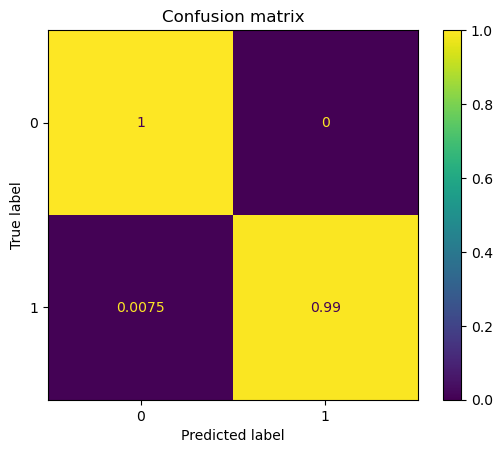

In [23]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, pred, normalize='true')
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion matrix')
plt.show()

These are some incredibly suspicious looking numbers. We should cross-validate to actually check.

In [25]:
# manual cross-validation split for a quick and dirty test

tt_cv = [ books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 1977)] ]
val_cv = [ books_train[(1978 <= books_train.release_year) & (books_train.release_year <= 1979)] ]

tt_cv.append( books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 1985)] )
val_cv.append( books_train[(1986 <= books_train.release_year) & (books_train.release_year <= 1987)] )

tt_cv.append( books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 1993)] )
val_cv.append( books_train[(1994 <= books_train.release_year) & (books_train.release_year <= 1995)] )

tt_cv.append( books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 2001)] )
val_cv.append( books_train[(2002 <= books_train.release_year) & (books_train.release_year <= 2003)] )

tt_cv.append( books_train[(1971 <= books_train.release_year) & (books_train.release_year <= 2011)] )
val_cv.append( books_train[(2012 <= books_train.release_year) & (books_train.release_year <= 2014)] )

In [27]:
f1s = dict()
precs = dict()

my_classifier = SynopsisLogRegClassifier(n_neighbors = 2, weights='distance', n_jobs = -1, class_weight='balanced')

for i in range(5):
    X_tt_cv = tt_cv[i][features]
    y_tt_cv = tt_cv[i].target

    X_ho = val_cv[i][features]
    y_ho = val_cv[i].target

    my_classifier.fit(X_tt_cv, y_tt_cv)

    pred = my_classifier.predict(X_ho)

    f1s['Fold {} F_1'.format(i)] = f1_score(y_ho, pred)
    precs['Fold {} Precision'.format(i)] = precision_score(y_ho, pred)
    

In [29]:
avg = 0
for key in f1s:
    print(key, f1s[key], sep=": ")
    avg += f1s[key]
avg = avg / 5
print(avg)


Fold 0 F_1: 0.21621621621621623
Fold 1 F_1: 0.2222222222222222
Fold 2 F_1: 0.20689655172413793
Fold 3 F_1: 0.16455696202531644
Fold 4 F_1: 0.16342412451361868
0.1946632153403023


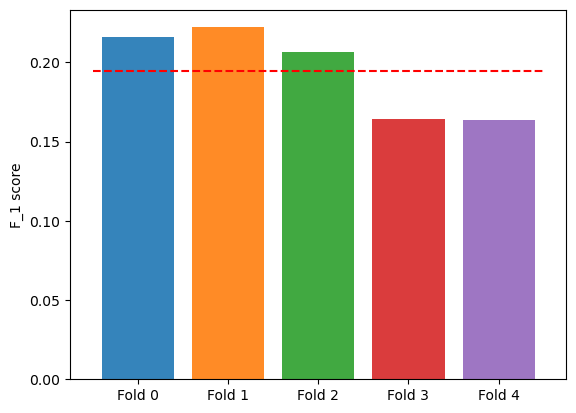

In [30]:
for key in f1s:
    plt.bar(x = 'Fold {}'.format(key.split(' ')[1]), height = f1s[key], alpha = 0.9)

plt.plot([-.5,4.5], [avg] * 2, linestyle='dashed', color='red')
plt.ylabel('F_1 score')
plt.show()

In [31]:
avg = 0
for key in precs:
    print(key, precs[key], sep=": ")
    avg += precs[key]
avg = avg / 5
print(avg)

Fold 0 Precision: 0.2222222222222222
Fold 1 Precision: 0.208955223880597
Fold 2 Precision: 0.16666666666666666
Fold 3 Precision: 0.12871287128712872
Fold 4 Precision: 0.13636363636363635
0.1725841240840502


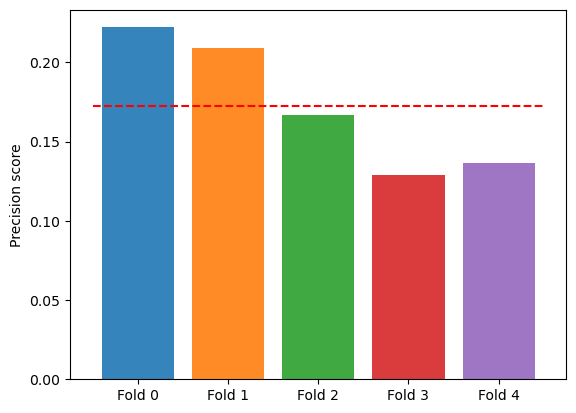

In [32]:
for key in precs:
    plt.bar(x = "Fold {}".format(key.split(' ')[1]), height = precs[key], alpha = 0.9)

plt.plot([-.5,4.5], [avg] * 2, linestyle='dashed', color='red')
plt.ylabel('Precision score')

plt.show()

As expected, we get much lower scores when we do cross-validation. This makes me wonder what was happening when we did the fitting on books_tt to get such ridiculously high scores.

We try to see if we can improve our performance by bagging our model.

In [35]:
from models.log_reg_with_synopsis import CustomBaggingClassifier

n_ests = [2, 5, 10, 100, 200, 500]

avg_f1s = dict()
avg_precs = dict()

kwargs = {'n_neighbors' : 2, 'weights' : 'distance', 'n_jobs' : -1, 'class_weight' :'balanced'}

# This takes a while (~30min on R9 7900X3D with 32GB RAM)
for n in n_ests:
    avg_f1 = 0
    avg_prec = 0
    bag = CustomBaggingClassifier(
            base_estimator = SynopsisLogRegClassifier,
            n_estimators = n,
            kwargs = kwargs
        )
    for i in range(5):

        X_tt_cv = tt_cv[i][features]
        y_tt_cv = tt_cv[i].target

        X_ho = val_cv[i][features]
        y_ho = val_cv[i].target

        bag.fit(X_tt_cv, y_tt_cv)
        pred = bag.predict(X_ho)

        avg_f1 += f1_score(y_ho, pred)
        avg_prec += precision_score(y_ho, pred)

    avg_f1s['{} estimators'.format(n)] = avg_f1 / 5
    avg_precs['{} estimators'.format(n)] = avg_prec / 5

In [36]:
avg_f1s

{'2 estimators': 0.16584235414213924,
 '5 estimators': 0.17923530298665485,
 '10 estimators': 0.18771221282187667,
 '100 estimators': 0.1950851562685723,
 '200 estimators': 0.1950851562685723,
 '500 estimators': 0.1950851562685723}

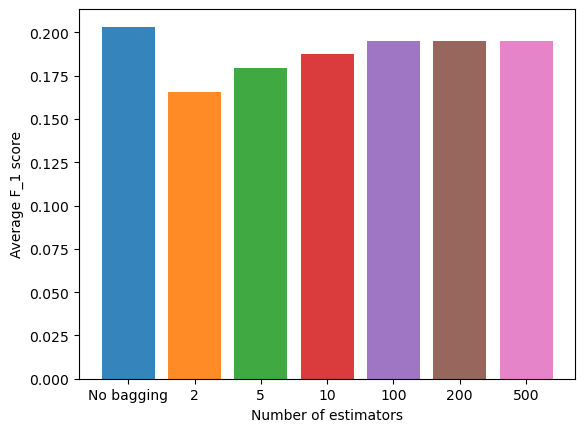

In [37]:
plt.bar(x = 'No bagging', height = 0.2033215903544372, alpha = 0.9)

for key in avg_f1s:
    plt.bar(x = key.split(' ')[0], height = avg_f1s[key], alpha=0.9)

plt.xlabel('Number of estimators')
plt.ylabel('Average F_1 score')

plt.show()

In [38]:
avg_precs

{'2 estimators': 0.18607629197398828,
 '5 estimators': 0.16697344322344324,
 '10 estimators': 0.18316715542521994,
 '100 estimators': 0.17310417608925072,
 '200 estimators': 0.17310417608925072,
 '500 estimators': 0.17310417608925072}

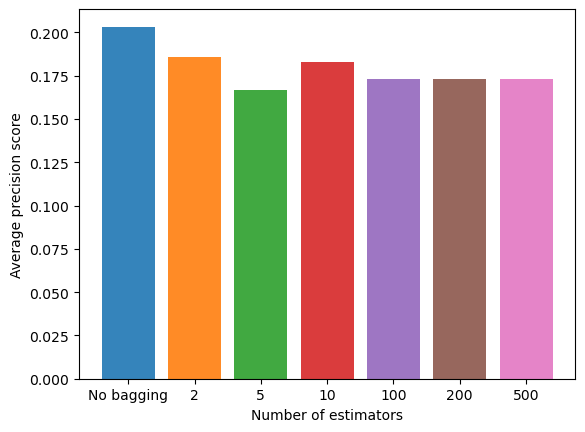

In [39]:
plt.bar(x = 'No bagging', height = 0.2033215903544372, alpha = 0.9)

for key in avg_precs:
    plt.bar(x = key.split(' ')[0], height = avg_precs[key], alpha=0.9)


plt.xlabel('Number of estimators')
plt.ylabel('Average precision score')

plt.show()

So we see here that bagging does not do anything to improve our scores.

We can see what happens when we do walkforwards cross-validation as in time series data.

In [40]:
from models.walkforward_cv import walk_forward


splits = walk_forward(books_train, step=4)

In [41]:
features

['num_prev_awards',
 'encoded_synopsis',
 'first_publisher',
 'author_birthplace_country',
 'Author_Age_at_Publication',
 'auto_tags']

In [42]:
splits[0][0].head()

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,...,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent,encoded_synopsis,auto_tags,target,num_prev_awards
4548,2009247,The Hawkstone,Jay Williams,1971,1971-10-01,"Henry Z. Walck, Inc.",1914,"Buffalo, New York, USA",0809830965,"""A young New Englander is unaware of the stran...",...,0,0,False,False,USA,Central/North America,"[-0.036100663, 0.10305314, 0.032459974, 0.0384...","[0.043439757, 0.1622729, 0.08368313, 0.0287689...",False,0
4552,1997735,The Seal-Singing,Rosemary Harris,1971,1971-00-00,Faber and Faber,1923,"London, England, UK",0571096395,"""While spending the summer on a Scottish islan...",...,0,0,False,False,UK,Europe,"[-0.07222478, 0.048827797, -0.00031475644, 0.0...","[0.046700247, 0.12478141, 0.11556144, 0.032019...",False,0
4553,449,Exiled from Earth,Ben Bova,1971,1971-04-00,Berkley Books,1932,"Philadelphia, Pennsylvania, USA",0425045250,3 science fiction-romaner.\n\n,...,0,0,False,False,USA,Central/North America,"[-0.08211492, -0.05334223, -0.0065231794, 0.01...","[0.12359146, 0.22534999, 0.14296484, 0.2565105...",False,0
4557,13636,The Exorcist,William Peter Blatty,1971,1971-00-00,HarperPaperbacks,1928,"New York City, New York, USA",0061007226,The Exorcist is a 1971 horror novel by America...,...,0,0,False,False,USA,Central/North America,"[-0.0025305643, 0.010534443, -0.02623904, 0.05...","[0.017564949, 0.1769332, 0.010551222, 0.096393...",False,0
4561,13885,The Vampire Curse,Daoma Winston,1971,1971-00-00,Severn House,1922,"Washington, District of Columbia, USA",0727844490,Teena Halliday had heard rumours that Jeremy R...,...,0,0,False,False,USA,Central/North America,"[-0.027311608, 0.05795092, 0.008173795, 0.0292...","[0.14014581, 0.3951993, 0.11319662, 0.11732886...",False,0


In [44]:
my_classifier = SynopsisLogRegClassifier(n_neighbors = 2, weights='distance', n_jobs = -1, class_weight='balanced')


val_years = []
f1s = []
precs = []

for fold in splits:
    walk = fold[0]
    val = fold[1]
    
    X_tt = walk[features]
    y_tt = walk.target

    X_val = val[features]
    y_val = val.target

    my_classifier.fit(X_tt, y_tt)
    pred = my_classifier.predict(X_val)

    year = val.release_year.iloc[0]
    val_years.append(year)

    f1s.append(f1_score(y_val, pred))
    precs.append(precision_score(y_val, pred))
    

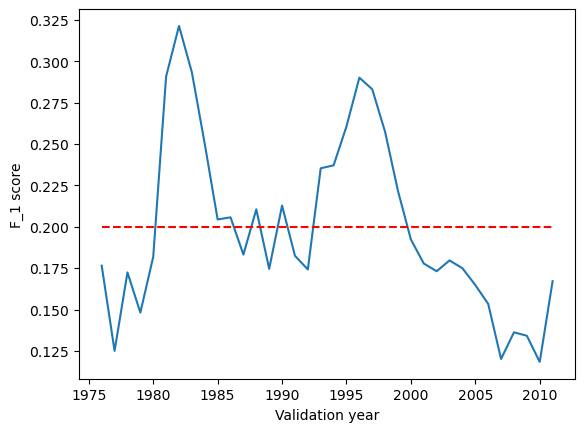

In [47]:
plt.plot(val_years, f1s)
avg_f1 = np.mean(f1s)
plt.plot([val_years[0], val_years[-1]], [avg_f1] * 2, color='red', linestyle='dashed')
plt.ylabel('F_1 score')
plt.xlabel('Validation year')
plt.show()

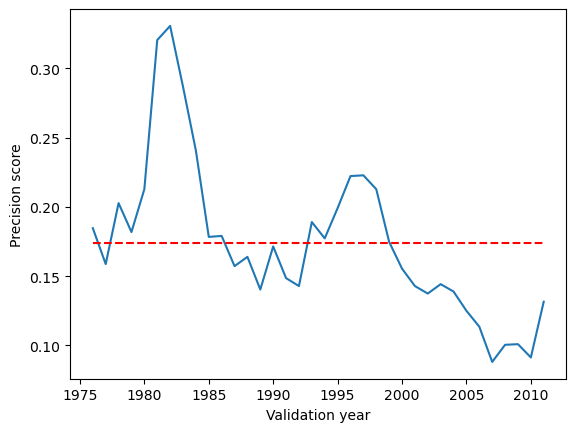

In [48]:
plt.plot(val_years, precs)
avg_prec = np.mean(precs)
plt.plot([val_years[0], val_years[-1]], [avg_prec] * 2, color='red', linestyle='dashed')
plt.ylabel('Precision score')
plt.xlabel('Validation year')
plt.show()

Here, we see that adding in synopsis data to logistics regression does not do anything to make a decent model, and therefore, we will drop this model from consideration.